# **Máster en Behavioral Data Science** - Instituto de Formación Continua (IL3) - Universitat de Barcelona
## **Módulo 7: Aprendizaje Automático - Reto I**
Autor: **Meysam Madadi**

Colaborador: **Julio C. S. Jacques Junior**

---

# Antes de empezar
- Cada vez que se requiera una respuesta (o fragmento de código) habrá un texto en rojo o un comentario en una celda de código. Deberás (hacer doble clic en la celda y) proporcionar la información solicitada.
- Se recomienda crear una copia de este archivo para que puedas practicar todo lo que necesites antes de entregar la tarea.
- **No cambies la estructura ni el formato** de este archivo.
- Cuando hayas terminado, haz clic en "File", "Download", **"Dowload .ipynb"**.
- Nombra el archivo descargado como "**Nombre_Apellido_Reto_1.ipynb**" antes de enviarlo.

---
# Información personal
<font color='red'>(Haga doble clic en esta celda e informe...)</font>

<font color='red'>**Nombre completo:**</font> Lourdes Casado Vidigal; Mónica
Pachón Basallo; Michel Fernando Redondo Silva; María Meritxell Ruiz Muñoz; Pamela Valembois Madrigal

---

# **Reto 1:** Técnicas de aprendizaje automático no supervisado para datos relacionados con la personalidad.
* El conjunto de datos proporcionado es una versión modificada de la base de datos “OCEAN Five Factor Personality Test Responses” (https://www.kaggle.com/datasets/lucasgreenwell/ocean-five-factor-personality-test-responses), denominado en este reto como “**data4.csv**”. También proporcionamos los datos originales (“**data4_original.csv**”).

# Descargando los datos
- Los datos se descargarán al ejecutarse la siguiente celda
- Los datos descargados se pueden encontrar usando la interfaz de Colab (en la parte izquierda de esta ventana, en la pestaña "Files")
- Al ejecutar el código en el siguiente bloque, se imprimirá en pantalla una matriz con tamaño **(19719, 55)** almacenada en "**datos**", y los nombres de los atributos (o características) de las columnas estarán almacenados en la variable "**datacolumns**".

In [2]:
# descargando los datos (originales y modificados)
!wget https://data.chalearnlap.cvc.uab.cat/Colab_MFPDS/2024BehaviorDSMaster/reto1/data4_original.csv
!wget https://data.chalearnlap.cvc.uab.cat/Colab_MFPDS/2024BehaviorDSMaster/reto1/data4.csv

--2026-06-27 09:46:53--  https://data.chalearnlap.cvc.uab.cat/Colab_MFPDS/2024BehaviorDSMaster/reto1/data4_original.csv
Resolving data.chalearnlap.cvc.uab.cat (data.chalearnlap.cvc.uab.cat)... 158.109.8.83
Connecting to data.chalearnlap.cvc.uab.cat (data.chalearnlap.cvc.uab.cat)|158.109.8.83|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2193877 (2.1M) [application/octet-stream]
Saving to: ‘data4_original.csv.1’

data4_original.csv. 100%[===================>]   2.09M  1.76MB/s    in 1.2s    

2026-06-27 09:46:55 (1.76 MB/s) - ‘data4_original.csv.1’ saved [2193877/2193877]

--2026-06-27 09:46:55--  https://data.chalearnlap.cvc.uab.cat/Colab_MFPDS/2024BehaviorDSMaster/reto1/data4.csv
Resolving data.chalearnlap.cvc.uab.cat (data.chalearnlap.cvc.uab.cat)... 158.109.8.83
Connecting to data.chalearnlap.cvc.uab.cat (data.chalearnlap.cvc.uab.cat)|158.109.8.83|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2193651 (2.1M) [application/octet-s

In [3]:
import numpy as np

def load_data(file_name):
    data = []
    with open(file_name, 'r') as fid:
        lines = fid.readlines()

        # la primera fila contiene el nombre de las columnas
        datacolumns = lines[0][:-1].split(',')

        for i in range(1, len(lines)):
            l = lines[i][:-1].split(',')
            data.append(l)
    data = np.array(data, dtype=np.float32)

    return data, datacolumns

# la siguiente línea carga los datos (modificados) que acabamos de descargar
data, datacolumns = load_data('data4.csv')

# imprimiendo el tamaño de la matriz
print(data.shape)

# imprimiendo las columnas (atributos)
print(datacolumns)

(19719, 55)
['race', 'age', 'engnat', 'gender', 'hand', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9', 'O10']


In [4]:
# imprimiendo algunos valores almacenados en "datacolumns"
print(datacolumns[5:15])
print("---")

# imprimiendo los valores de algunas muestras almacenadas en"data"
print(data[0:3,5:15])

print("---")
# calculando e imprimiendo el valor promedio de algunas muestras y atributos
print("Valor promedio = ", np.mean(data[0:3,5]))

# calculando e imprimiendo la varianza de algunas muestras y atributos
print("Varianza = ", np.var(data[0:3,5]))

['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10']
---
[[4. 2. 5. 2. 5. 1. 4. 3. 5. 1.]
 [2. 2. 3. 3. 3. 3. 1. 5. 1. 5.]
 [5. 1. 1. 4. 5. 1. 1. 5. 5. 1.]]
---
Valor promedio =  3.6666667
Varianza =  1.5555557


---
# **TAREA 1:** Visualizando los datos con diagramas de caja (*boxplot*) e histogramas

- Primero, queremos ver cómo se ven los datos al visualizar las distribuciones de frecuencia en diferentes tipos de gráficos: gráficos de caja e histograma.

- **Boxplot:** un diagrama de caja (también conocido como *boxplot*) es un gráfico que resume un conjunto de datos. La línea que divide la caja en dos representa el valor de la mediana. Esto indica que el 50% de los datos se encuentra a la izquierda de la mediana y el otro 50% a la derecha. El borde izquierdo de la caja (o inferior, dependiendo de cómo se visualice) representa el cuartil inferior; muestra el valor hasta el cual se encuentra el primer 25% de los datos.
El borde derecho de la caja (o superior, dependiendo de cómo se visualice) representa el cuartil superior; indica que el 25% de los datos se encuentra a la derecha de ese valor. Los puntos individuales en el diagrama representan los valores atípicos (*outliers*).

- **Histograma:** muestra el número de muestras que pertenecen a diferentes rangos (distribución de datos) dado un número predefinido de "bins".

- En la siguiente celda se encuentra el código para dibujar la distribución de frecuencias como un diagrama de caja para las columnas de metadatos. Como verás, no se pueden obtener muchas conclusiones al visualizar el gráfico, ya que los datos contienen algo de ruido y *outliers*, y debido a esto, la visualización está demasiado condensada. Por el momento, intenta comprender cómo podemos generar un gráfico como este. En las próximas celdas, mostraremos una estrategia muy básica para "limpiar" ese ruido y mejorar la visualización.


/tmp/ipykernel_17038/366302177.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(datacolumns[:5])


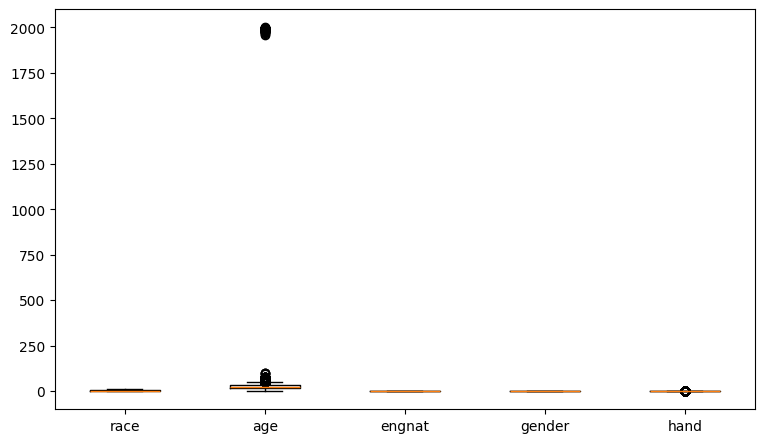

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize =(7, 4))

# Creando los ejes
ax = fig.add_axes([0, 0, 1, 1])

# etiquetas del eje x de datacolumns
ax.set_xticklabels(datacolumns[:5])

# Creando el gráfico
ax.boxplot(data[:, :5])

# mostrando el gráfico
plt.show()

## T1.A
- **En esta tarea, necesitas copiar el código anterior en la siguiente celda y adaptarlo para mostrar un diagrama de caja para todos los rasgos de personalidad (sin mostrar la información de metadatos).** <font color='blue'>(0.5 puntos)</font>
- Tenga en cuenta que las primeras cinco columnas son metadatos y lo restante ("datos[:, 5:]") son cuestionarios relacionados con la personalidad.


<font color='red'>Proporcione la solución (código) en la siguiente celda.</font>

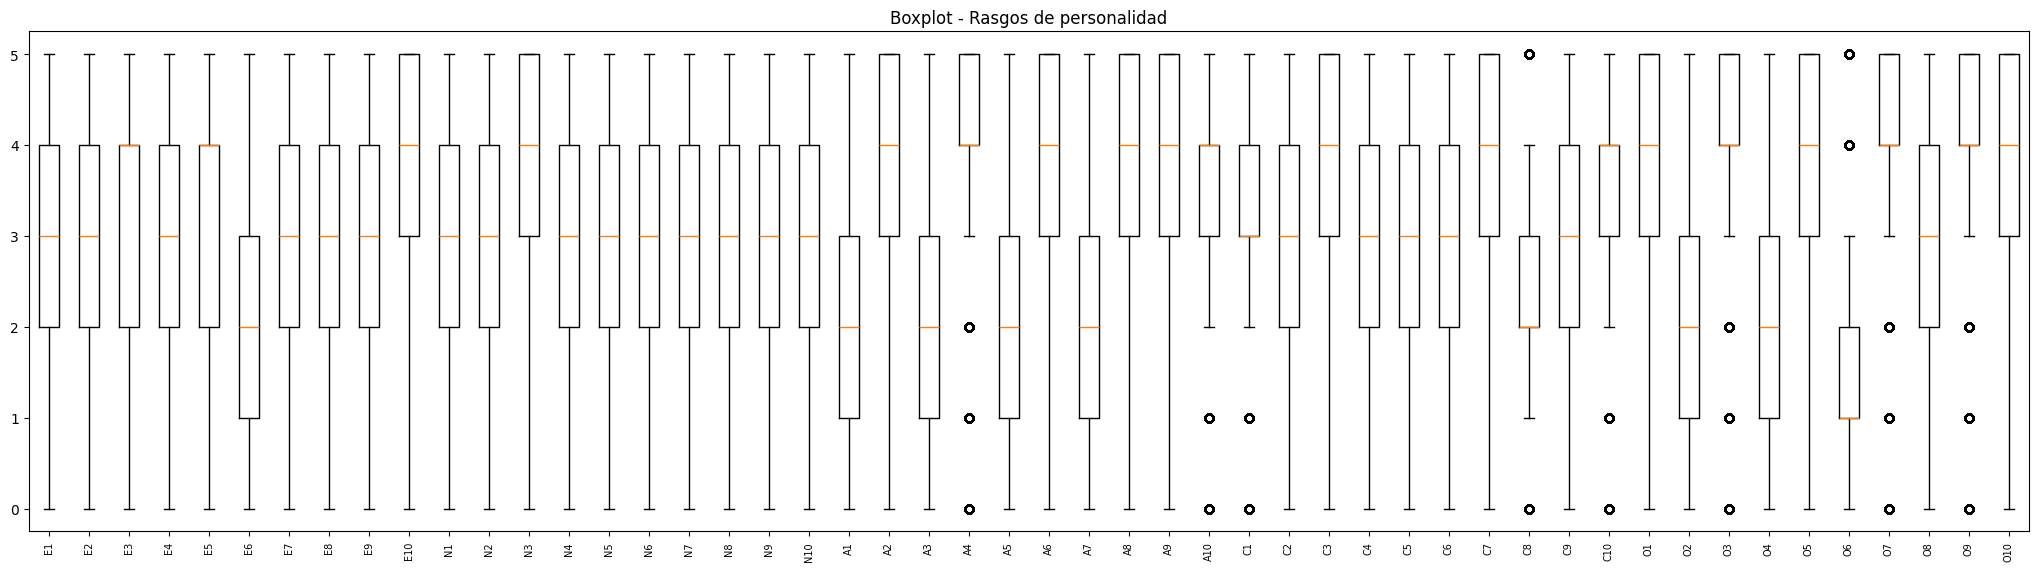

In [6]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------

# Copie el código anterior aquí (debajo de este comentario)
# y adáptelo para mostrar el diagrama de caja de los rasgos de personalidad. import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(20, 5))
ax = fig.add_axes([0, 0, 1, 1])
ax.boxplot(data[:, 5:])
ax.set_xticks(range(1, len(datacolumns[5:]) + 1))
ax.set_xticklabels(datacolumns[5:], rotation=90, fontsize=7)
plt.title("Boxplot - Rasgos de personalidad")
plt.show()


## Para practicar (*thresholding* y "limpieza de datos")
- El siguiente código crea una copia de los datos usando "data_cp = data" y luego cambia todos los valores superiores a un umbral (100) a cero usando "data_cp[data_cp>100]=0".
 - Ten en cuenta que esta estrategia de limpieza no necesariamente funcionará para otros problemas o conjuntos de datos. En este caso, conocemos el rango de nuestros datos, y por eso podemos "limpiarlos" fácilmente reemplazando con 0 los valores que están fuera de dicho rango. Existen estrategias más sofisticadas para tratar con valores atípicos (*outliers*), pero no se abordarán en esta práctica.

- Finalmente, generamos una visualización usando el mismo código proporcionado anteriormente. Después de limpiar los datos, podemos notar que la nueva visualización nos ayuda a interpretar mejor la información.

- Puedes cambiar el valor del umbral y analizar los resultados (esta celda no se evaluará) con el fin de familiarizarte con el manejo de los datos. Asegúrate de practicar con una copia de los datos para evitar modificar los datos "originales"


/tmp/ipykernel_17038/2550145973.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(datacolumns[:5])


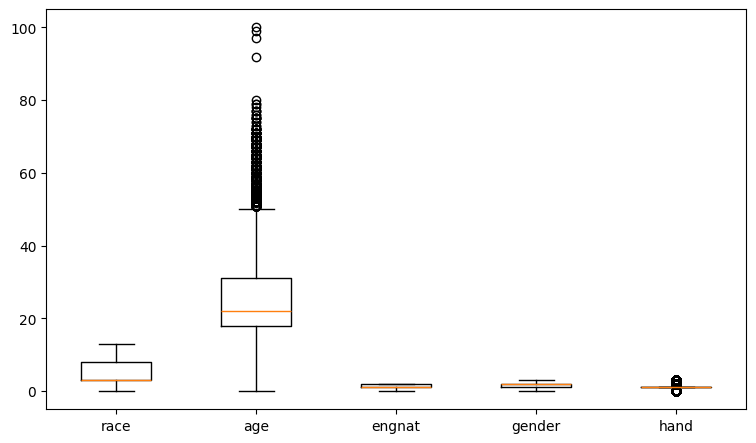

In [7]:
# creando una copia de nuestro conjunto de datos
data_cp = data.copy()

# cambiando todos los valores superiores a "100" a "0"
data_cp[data_cp>100]=0

fig = plt.figure(figsize =(7, 4))

# Creando los ejes
ax = fig.add_axes([0, 0, 1, 1])

# etiquetas del eje x de datacolumns
ax.set_xticklabels(datacolumns[:5])

# Creando el gráfico
ax.boxplot(data_cp[:, :5])

# mostrando el gráfico
plt.show()

# Histograma
- El siguiente código se utiliza para generar y visualizar los histogramas de cada pregunta relacionada con la personalidad de ***extroversión***.

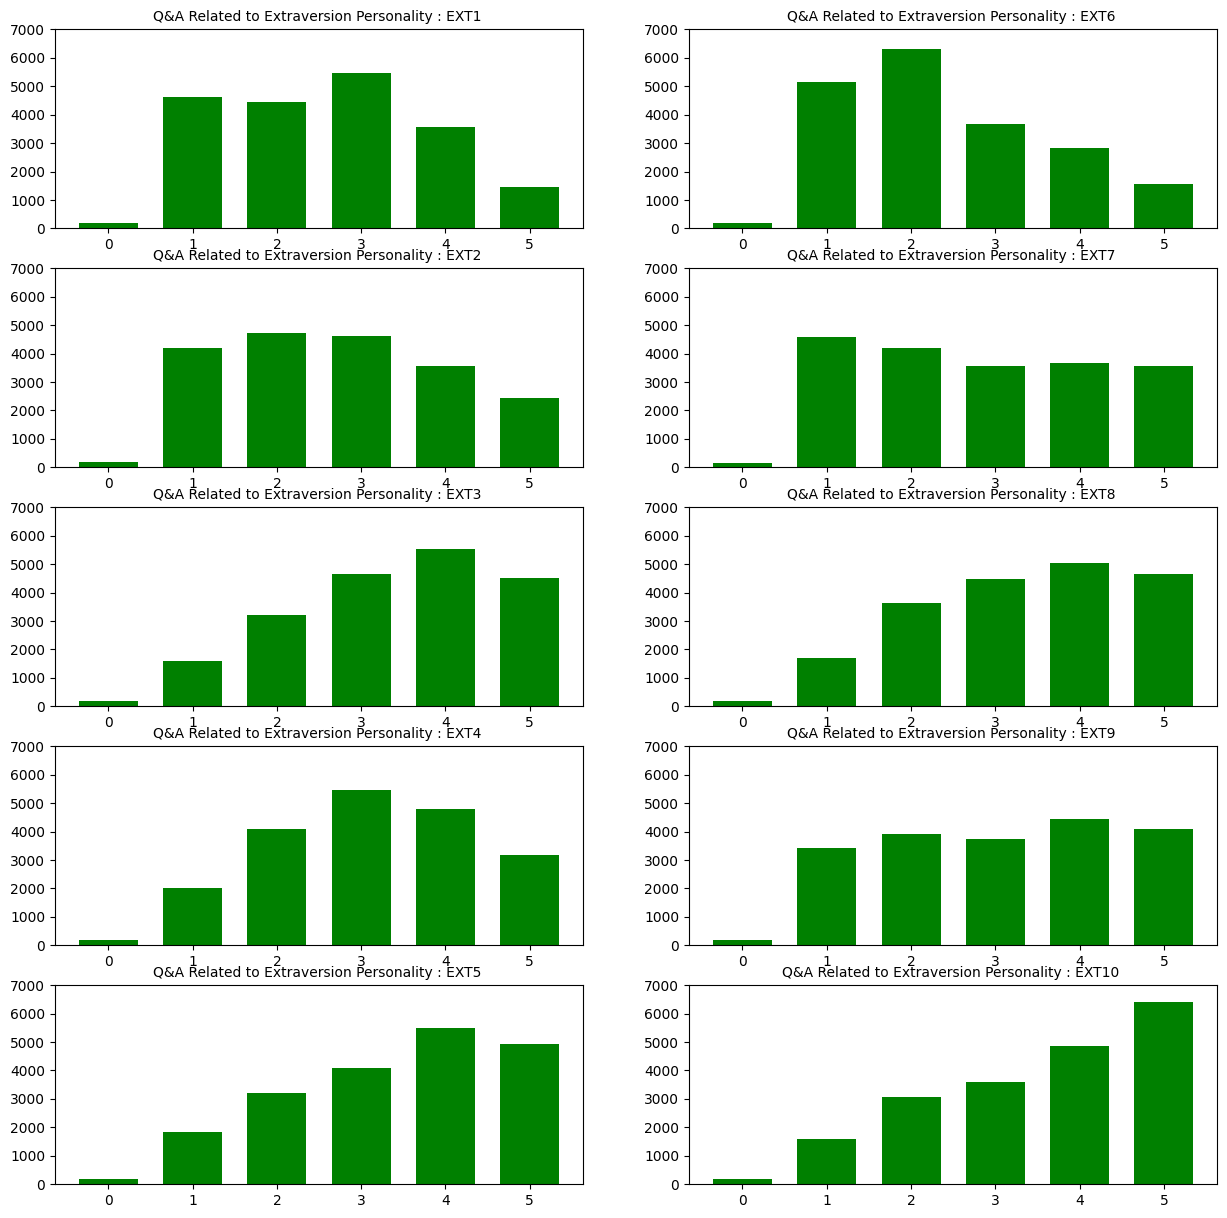

<Figure size 400x200 with 0 Axes>

In [8]:
fig, axs = plt.subplots(5, 2, figsize =(15, 15))

# lista de preguntas para la personalidad de extraversión
fft=['EXT1','EXT2','EXT3','EXT4','EXT5','EXT6','EXT7','EXT8','EXT9','EXT10']
n=0 # un contador para realizar un seguimiento de las preguntas
for f in fft:
    # "[n%5, n//5]" define el índice del subplot
    # "bins" define los rangos en los que se distribuyen los valores
    # ([0, 1, 2, 3, 4, 5, 6]) - aquí, el "-0.5" se usa para centrar las
    # etiquetas con las barras en el eje x
    # En "data[:, 5+n]", 5 es el índice de la primera pregunta de extraversión
    bins = np.arange(7) - 0.5
    axs[n%5, n//5].hist(data[:, 5+n], bins, rwidth=0.7, color='green')
    # Fijar el rango de valores mostrados en el eje Y
    axs[n%5, n//5].set_ylim(0, 7000)
    axs[n%5, n//5].set_title("Q&A Related to Extraversion Personality : {} ".format(f), fontsize = 10)
    n=n+1
plt.figure(figsize =(4, 2))
plt.tight_layout()
plt.show()

## T1.B
- **Copia el código anterior en la siguiente celda y adáptalo para visualizar el histograma de *openness*.** <font color='blue'>(0.5 puntos)</font>

<font color='red'>Proporcione la solución (código) en la siguiente celda.</font>

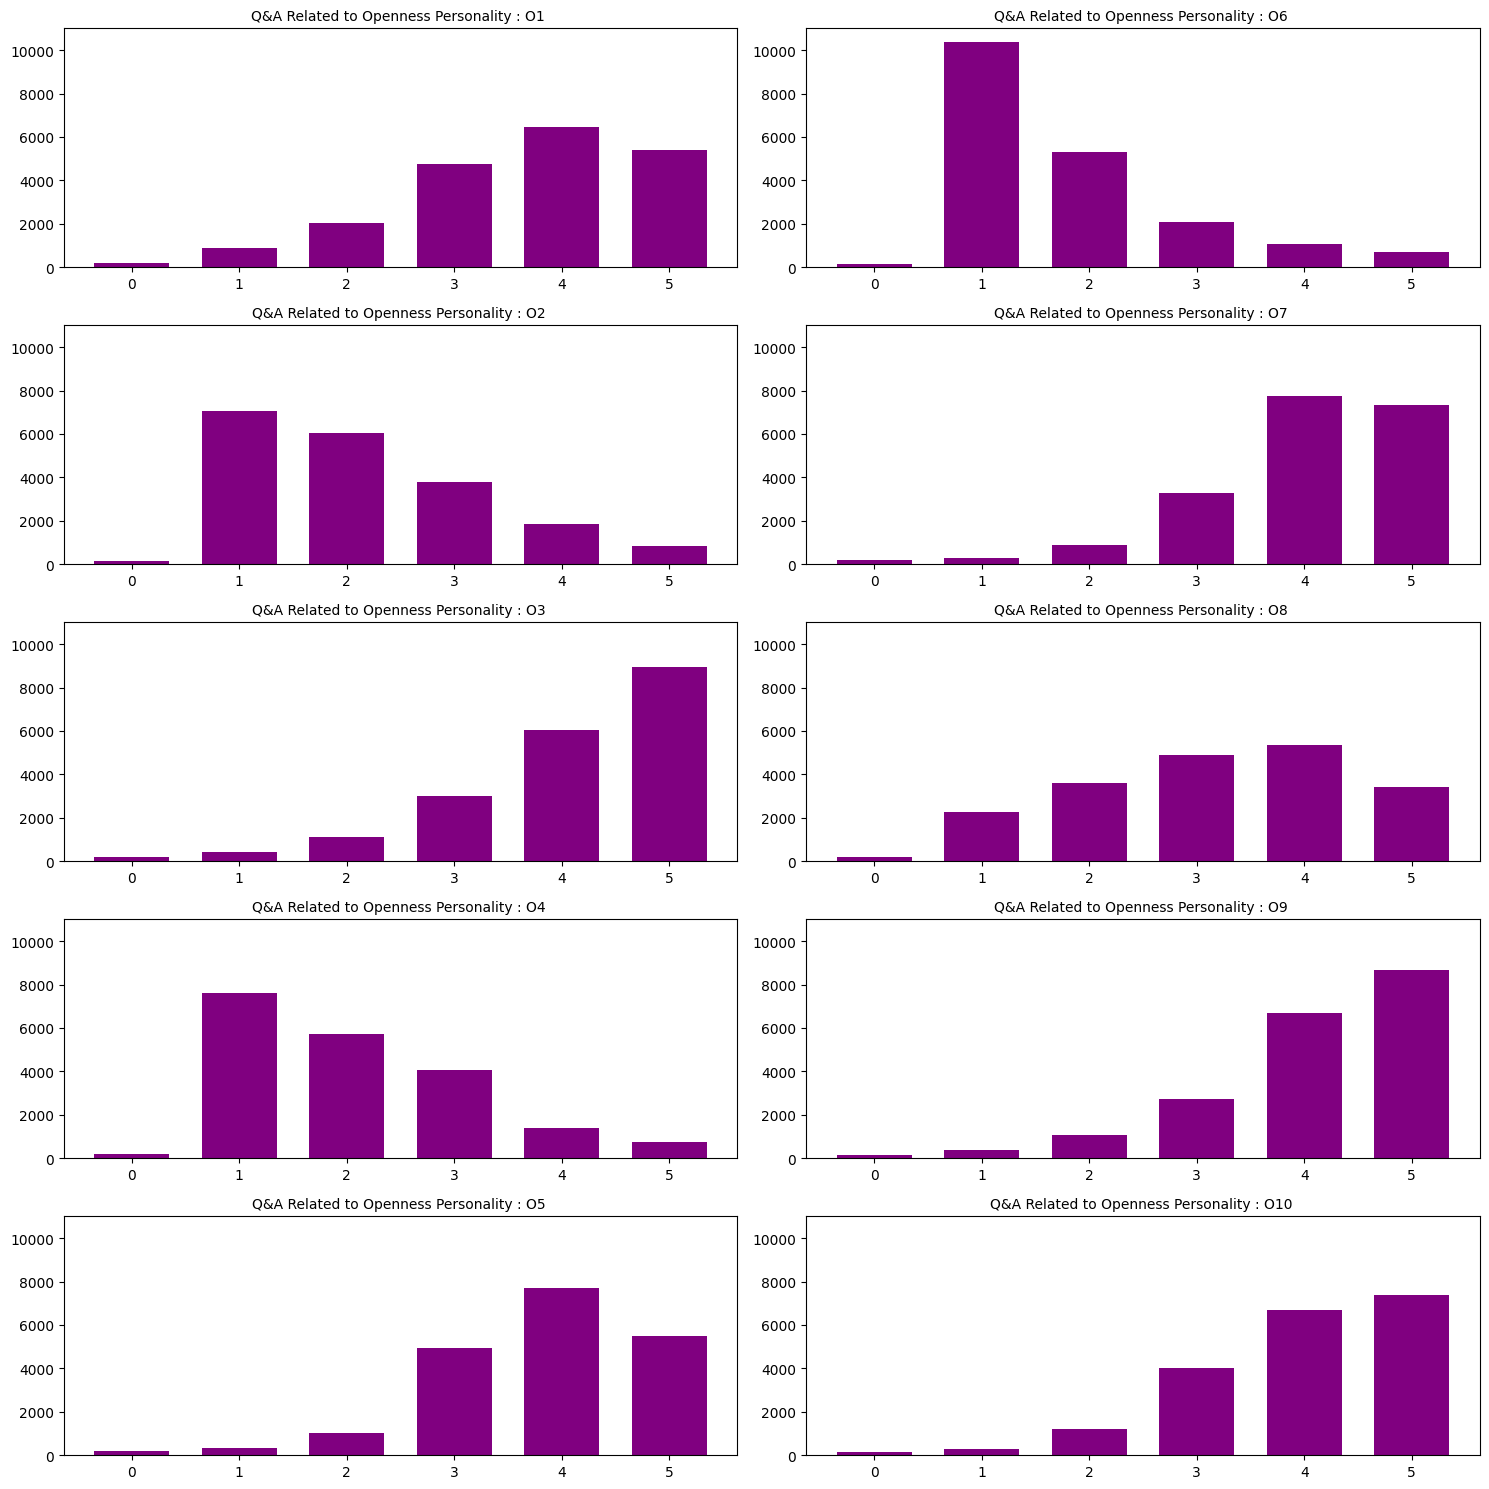

In [9]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------

# Copie el código anterior aquí (debajo de este comentario)
# y adáptelo para mostrar histogramas de "openness"
fig, axs = plt.subplots(5, 2, figsize=(15, 15))
fft = ['O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9', 'O10']
n = 0
for f in fft:
    bins = np.arange(7) - 0.5
    axs[n%5, n//5].hist(data[:, 45+n], bins, rwidth=0.7, color='purple')
    axs[n%5, n//5].set_ylim(0, 11000)
    axs[n%5, n//5].set_title("Q&A Related to Openness Personality : {} ".format(f), fontsize=10)
    n = n + 1
plt.tight_layout()
plt.show()


## T1.C

- Teniendo en cuenta los gráficos anteriores, responda la siguiente pregunta.
- Las preguntas E6 y E10, correspondientes al rasgo de extraversión, presentan distribuciones diferentes. **¿Cómo se reflejan estas diferencias en los gráficos de histograma de dichas preguntas?** También puedes apoyar tu respuesta con el diagrama de caja, resuelto en el apartado T1.A. <font color='blue'>(0.5 puntos)</font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font> E6 ("I have little to say") y E10 ("I am quiet around strangers"), aunque ambas parecen ítems de baja extraversión, presentan distribuciones opuestas en sus histogramas. E6 está sesgada hacia valores bajos: la mayoría de las respuestas se concentran en 1 y 2 (moda = 2, mediana = 2), lo que indica que la mayoría de las personas no se identifica con "tener poco que decir". En cambio, E10 está sesgada hacia valores altos: la mayoría de las respuestas se concentran en 4 y 5 (moda = 5, mediana = 4), o sea, la mayoría sí se considera callada ante desconocidos. Esta diferencia se confirma en el diagrama de caja de T1.A, donde E6 tiene la caja y la mediana en la parte baja del rango, mientras que E10 las tiene en la parte alta.

## T1.D

- Teniendo en cuenta los gráficos anteriores, responda la siguiente pregunta.

- Dado el rasgo de *Openness*, **¿qué pregunta presenta la mayor varianza en sus respuestas (O1, O2, ..., O10)?** <font color='blue'>(1 punto)</font>

 - *La varianza es una medida de dispersión. Es decir, es una medida de cuánto se separa un conjunto de números de su valor promedio (para proporcionar la respuesta exacta, aparte de la inspección visual, puedes consultar algunos ejemplos sobre cómo calcular la varianza usando python: https://numpy.org/doc/stable/reference/generated/numpy.var.html#numpy.var*

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font> La pregunta O8 presenta la mayor varianza en las respuestas, con una varianza del 1.6671. Esto indica que las respuestas muestran una mayor dispersión respecto a su media que el resto de preguntas del rasgo Openness.

 <font color='red'>Proporcione la solución (código) en la siguiente celda.</font>

In [10]:
print("Varianzas de Openness (O1-O10):")
variances = [np.var(data[:, 45+i]) for i in range(10)]
for i, col in enumerate(datacolumns[45:55]):
    print(f"  {col}: {variances[i]:.4f}")
max_idx = np.argmax(variances)
print(f"\nPregunta con mayor varianza: {datacolumns[45+max_idx]} ({variances[max_idx]:.4f})")

Varianzas de Openness (O1-O10):
  O1: 1.3670
  O2: 1.3138
  O3: 1.1549
  O4: 1.2608
  O5: 1.0191
  O6: 1.1588
  O7: 1.0005
  O8: 1.6671
  O9: 1.1011
  O10: 1.0921

Pregunta con mayor varianza: O8 (1.6671)


---
# **TAREA 2:** Preprocesamiento de datos
- Como se mencionó anteriormente, los datos contienen algo de ruido, valores faltantes (*missing values*) y valores atípicos (*outliers*), lo que resultó en una visualización deficiente de los metadatos en el diagrama de caja utilizado en la Tarea 1.

- Algunas respuestas de personalidad también presentan valores iguales a cero.

- Por lo tanto, debemos preprocesar y limpiar los datos para asegurarnos de que estén listos para ser utilizados por nuestros algoritmos de *Machine Learning*.


## T2.A

- Más específicamente, se encontraron valores ruidosos en la columna "age" (edad). La fuente del ruido es que, en algunos casos, se reportó el año de nacimiento en lugar de la edad. Estos valores pueden corregirse restando el año informado a 2019 (año en que se recopiló el conjunto de datos). **Encuentra los valores mayores a 100 en la columna de edad y corrígelos. Luego, vuelve a visualizar el diagrama de caja de los metadatos, como se ilustró en la Tarea 1.** <font color='blue'>(1.0 punto)</font>

 <font color='red'>Proporcione la solución (código) en la siguiente celda.</font>

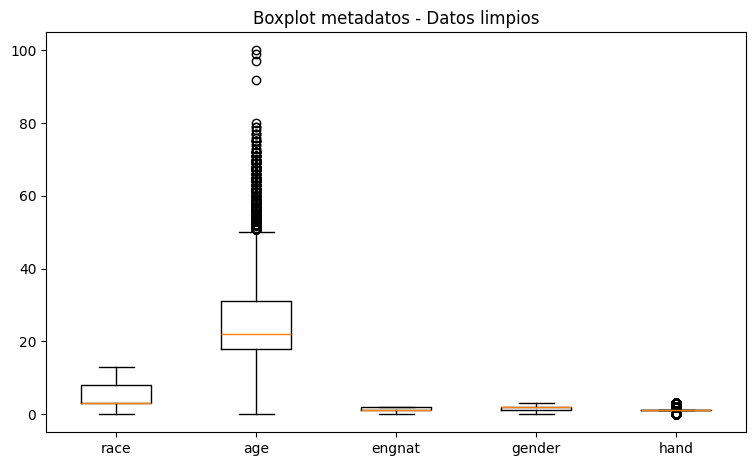

In [11]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------
# Paso 1: crear copia y corregir las edades > 100 (años de nacimiento)
data_cp_T2A = data.copy()
data_cp_T2A[data_cp_T2A[:, 1] > 100, 1] = 2019 - data_cp_T2A[data_cp_T2A[:, 1] > 100, 1]

# Paso 2: visualizar el boxplot de los metadatos ya limpios
fig = plt.figure(figsize=(7, 4))
ax = fig.add_axes([0, 0, 1, 1])
ax.boxplot(data_cp_T2A[:, :5])
ax.set_xticks(range(1, 6))
ax.set_xticklabels(datacolumns[:5])
plt.title("Boxplot metadatos - Datos limpios")
plt.show()


## Llenando los valores faltantes
- Consideremos que los valores faltantes en este conjunto de datos se representan con el valor 0.
- En el siguiente código, dichos valores se reemplazan utilizando la muestra más cercana del conjunto de datos. Puedes consultar la documentación del método utilizado aquí: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KDTree.html

- Curiosamente, las muestras donde "age = 0" no tienen este valor reemplazado, ya que la muestra más cercana también tiene "age = 0". Esto sugiere que este atributo tiene una fuerte influencia en la forma en que se calcula la distancia a otras muestras (en este caso). Esto se ilustra a continuación, mostrando el número de valores faltantes para dos atributos (race y age) antes y después de aplicar esta estrategia.
- Luego, comparamos el resultado con los valores originales (cargados como "data_original") utilizando la función L1, que calcula el error absoluto medio por columna.
- Ten en cuenta que la versión modificada de los datos que estamos usando incluye algo de ruido añadido manualmente. Por eso comparamos los resultados con el conjunto original, para evaluar la efectividad de nuestra estrategia para manejar los datos faltantes. En el mejor de los casos, nos gustaría que los datos completados sean lo más similares posible a los originales (es decir, con un error menor).



In [12]:
# obteniendo el número de valores faltantes de los atributos 'x' e 'y'
# antes de completar los datos faltantes
x = 0 # race
y = 1 # age
counter_x = 0
counter_y = 0
for count, value in enumerate(data[:,x]):
  if(value==0):
    counter_x +=1
for count, value in enumerate(data[:,y]):
  if(value==0):
    counter_y +=1
print("numero de valores faltantes: 'race' = %d,  'age' = % d" % (counter_x,counter_y))

numero de valores faltantes: 'race' = 329,  'age' =  182


In [13]:
from sklearn.neighbors import KDTree

# Construyendo el modelo kd-tree
tree = KDTree(data, leaf_size=2)

# Estrayendo las 6 muestras más cercanas de todo el conjunto de datos
# Tenga en cuenta que la primera muestra más cercana es la propia muestra.
dist, ind = tree.query(data, k=6)

In [14]:
# Buscando índices con valores 0
ind_row, ind_col = np.where(data==0)

# Comprobando los valores 0 y reemplazándolos.
for i,j in zip(ind_row, ind_col):
    # Tenga en cuenta que la primera muestra más cercana es la propia muestra.
    # es por eso que no empezamos este bucle con cero
    for n in range(1, 6):
        # Asegurándonos de que la muestra más cercana no sea 0; de lo contrario, tomaremos la siguiente muestra más cercana
        if data[ind[i,n], j] != 0:
            data[i,j] = data[ind[i,n], j]
            break

def L1(X, Y, rows, cols):
    # Creando una variable "error" como un diccionario con una lista vacía por columna
    error = {}
    for i in range(X.shape[1]):
        error[i] = []

    # calculando el error de los valores faltantes
    for i,j in zip(rows, cols):
        error[j].append(np.abs(X[i,j] - Y[i,j]))

    # calculando el error promedio por columna
    for i in error.keys():
        if len(error[i]) > 0:
            error[i] = np.mean(error[i])

    return error

data_original, _ = load_data('data4_original.csv')
error_nearest = L1(data, data_original, ind_row, ind_col)
print("Error promedio al usar el reemplazo por el vecino más cercano: "+str(np.mean(list(error_nearest.values())[5:])))


# imprimiendo el error con los nombres de las columnas
txt = ""
for i in error_nearest.keys():
    txt += datacolumns[i] + "=" + ("{0:.2f}".format(error_nearest[i]) if type(error_nearest[i]) is not list else "[no missing value found]") + ", "
print(txt)

Error promedio al usar el reemplazo por el vecino más cercano: 1.1179305
race=2.75, age=37.77, engnat=0.59, gender=0.55, hand=0.48, E1=0.95, E2=1.11, E3=0.97, E4=1.05, E5=1.13, E6=0.88, E7=1.36, E8=1.30, E9=1.22, E10=1.39, N1=1.26, N2=1.14, N3=1.21, N4=1.11, N5=1.14, N6=1.16, N7=1.10, N8=1.01, N9=1.16, N10=1.12, A1=0.93, A2=1.10, A3=0.99, A4=1.02, A5=0.76, A6=1.40, A7=0.89, A8=1.14, A9=1.23, A10=1.07, C1=1.10, C2=1.46, C3=1.20, C4=1.03, C5=1.18, C6=1.32, C7=1.30, C8=0.85, C9=1.26, C10=1.08, O1=1.22, O2=0.97, O3=1.23, O4=0.91, O5=0.98, O6=0.81, O7=1.06, O8=1.13, O9=1.32, O10=1.17, 


In [15]:
# obteniendo el número de valores faltantes de los atributos 'x' e 'y'
# despues de completar los datos faltantes
x = 0 # race
y = 1 # age
counter_x = 0
counter_y = 0
for count, value in enumerate(data[:,x]):
  if(value==0):
    counter_x +=1
for count, value in enumerate(data[:,y]):
  if(value==0):
    counter_y +=1
print("numero de valores faltantes: 'race' = %d,  'age' = % d" % (counter_x,counter_y))

numero de valores faltantes: 'race' = 0,  'age' =  182


## T2.B

A continuación, en lugar de usar la muestra más cercana para reemplazar los valores faltantes, deberás:

1. **Calcular el valor promedio de cada columna y guardarlo en una variable auxiliar;**

2. **Completar los valores faltantes de cada columna con el promedio correspondiente;**

3. Finalmente, **comparar ambos métodos usando la función L1, de manera similar al código anterior.**

Ten en cuenta que toda esta parte <font color='blue'>**debe resolverse utilizando los datos limpios del ejercicio anterior (T2.A)**.</font>

<font color='red'>Proporcione la solución (código) en la siguiente celda.</font> <font color='blue'>(2 puntos)</font>





In [16]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------


# paso 0: partir de los datos limpios de T2.A
data = data_cp_T2A.copy()

# recalcular los índices de valores faltantes sobre los datos limpios
ind_row, ind_col = np.where(data == 0)

# paso 1: calcular el valor promedio de cada columna (ignorando los ceros)
col_means = {}
for j in range(data.shape[1]):
    col_vals = data[:, j]
    non_zero = col_vals[col_vals != 0]
    col_means[j] = np.mean(non_zero) if len(non_zero) > 0 else 0

# paso 2: completar los valores faltantes con el promedio de la columna
data_mean = data.copy()
for i, j in zip(ind_row, ind_col):
    data_mean[i, j] = col_means[j]

# paso 3: comparar con los datos originales usando L1
error_mean = L1(data_mean, data_original, ind_row, ind_col)
print("Error promedio al usar la media: " + str(np.mean(list(error_mean.values())[5:])))
txt = ""
for i in error_mean.keys():
    txt += datacolumns[i] + "=" + ("{0:.2f}".format(error_mean[i]) if type(error_mean[i]) is not list else "[no missing value found]") + ", "
print(txt)
# Actualizar 'data' con los datos imputados por media
data = data_mean.copy()

Error promedio al usar la media: 1.0017858
race=4.30, age=19.91, engnat=0.73, gender=0.59, hand=0.55, E1=1.15, E2=1.12, E3=1.12, E4=1.03, E5=1.26, E6=1.05, E7=1.27, E8=1.07, E9=1.22, E10=1.15, N1=1.08, N2=1.02, N3=0.98, N4=1.07, N5=1.10, N6=1.20, N7=1.19, N8=1.14, N9=1.13, N10=1.17, A1=1.14, A2=0.79, A3=0.95, A4=0.78, A5=0.89, A6=0.93, A7=0.96, A8=0.80, A9=0.79, A10=0.90, C1=0.97, C2=1.16, C3=0.78, C4=1.07, C5=1.07, C6=1.20, C7=0.91, C8=0.94, C9=1.05, C10=0.78, O1=0.87, O2=1.02, O3=0.82, O4=0.89, O5=0.78, O6=0.89, O7=0.73, O8=1.16, O9=0.73, O10=0.80, 


## Ahora, no deberíamos tener ningún valor de edad = 0

In [17]:
# obteniendo el número de valores faltantes de los atributos 'x' e 'y'
# despues de completar los datos faltantes (usando la segunda estrategia)
x = 0 # race
y = 1 # age
counter_x = 0
counter_y = 0
for count, value in enumerate(data[:,x]):
  if(value==0):
    counter_x +=1
for count, value in enumerate(data[:,y]):
  if(value==0):
    counter_y +=1
print("numero de valores faltantes: 'race' = %d,  'age' = % d" % (counter_x,counter_y))

numero de valores faltantes: 'race' = 0,  'age' =  0


## T2.C
Con respecto a las Tareas 2.A y 2.B,

- **Si consideramos únicamente las columnas asociadas a las preguntas de personalidad (es decir, excluyendo las columnas de metadatos), ¿qué método utilizado para completar los valores faltantes obtiene un error promedio más bajo? Proporcione el valor del error promedio obtenido en cada caso.** <font color='blue'>(0.5 puntos)</font>
  
<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font> Considerando únicamente las columnas de personalidad (excluyendo metadatos), el método de imputación por la media obtiene un error promedio más bajo (1.0017858) en comparación con el método del vecino más cercano (1.1179305). Por tanto, en esta ejecución, el método de imputación por la media proporciona un mejor resultado para completar los valores faltantes en las preguntas de personalidad.


<font color='red'>Proporcione la solución (código) en la siguiente celda.

In [18]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------
error_nn_personality = np.mean(list(error_nearest.values())[5:])
error_mean_personality = np.mean(list(error_mean.values())[5:])
print(f"Error vecino más cercano (personalidad): {error_nn_personality:.7f}")
print(f"Error por media (personalidad): {error_mean_personality:.7f}")

Error vecino más cercano (personalidad): 1.1179305
Error por media (personalidad): 1.0017858


## T2.D
- Cada columna del conjunto de datos tiene un rango de valores y un significado diferente. En la siguiente celda, **normaliza los datos (que obtuvieron el error promedio más bajo en la tarea anterior, T2.C) de modo que todos los valores queden en el mismo rango ([0,...,1]). La normalización debe hacerse por columna.**  <font color='blue'>(1 punto)</font>.
 - Sugerencia: puedes dividir cada columna por su valor máximo.

<font color='red'>Proporcione la solución (código) en la siguiente celda.</font>


In [19]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------
# normalización por columna dividiendo por el valor máximo (data_mean obtuvo menor error en T2.C)
data = data_mean.copy()

for j in range(data.shape[1]):
    col_max = data[:, j].max()
    if col_max > 0:
        data[:, j] = data[:, j] / col_max

print("Normalización completada.")
for j in range(5):
    print(f"  {datacolumns[j]}: [{data[:,j].min():.3f}, {data[:,j].max():.3f}]")

Normalización completada.
  race: [0.077, 1.000]
  age: [0.130, 1.000]
  engnat: [0.500, 1.000]
  gender: [0.333, 1.000]
  hand: [0.333, 1.000]


---
# **TAREA 3:** Análisis de correlación
- El siguiente bloque de código muestra la correlación por pares entre todas las columnas. Como podemos ver, existen correlaciones positivas, negativas o nulas (alrededor de cero). La matriz muestra, por ejemplo, que la variable "raza" (*race*) no tiene correlación con la "edad", pero sí con el "inglés nativo" (*engnat*), y cierta correlación negativa con la pregunta "O8".





In [20]:
import pandas as pd

dataframe = pd.DataFrame(data = data, columns = datacolumns)
correlation = dataframe.corr()
correlation.style.background_gradient(cmap = 'jet')


,race,age,engnat,gender,hand,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,N1,N2,N3,N4,N5,N6,N7,N8,N9,N10,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10
race,1.000000,-0.085816,0.212134,0.050844,-0.017905,0.018421,0.014252,0.041833,0.018851,0.022190,0.075515,-0.005974,-0.006604,0.021553,0.029809,-0.011925,0.038354,0.001526,0.045456,0.068304,0.045816,0.036062,0.036559,0.013345,-0.020465,0.114477,-0.009840,-0.030488,0.036671,0.020015,0.057922,0.027052,-0.003743,0.042283,0.041277,0.010127,-0.074320,-0.006017,-0.024697,0.106676,-0.015221,0.009042,0.008576,0.048645,-0.009565,-0.202950,0.141054,-0.063456,0.106418,-0.043170,0.041612,-0.077405,-0.202683,-0.068520,-0.068502
age,-0.085816,1.000000,-0.070996,-0.030869,-0.004266,0.018276,-0.043519,0.106322,-0.072893,0.129592,-0.115221,0.078727,-0.011916,-0.010017,-0.155682,-0.115422,-0.015202,-0.111802,0.051281,-0.076119,-0.098213,-0.203220,-0.159500,-0.141215,-0.110416,-0.153241,0.055196,-0.182945,0.093046,-0.056430,0.082565,-0.081297,0.067318,0.074892,0.136567,0.096129,-0.066553,0.022477,-0.215345,0.154214,-0.146784,0.106852,-0.252164,0.100426,0.136352,0.131217,-0.055329,-0.027608,-0.012972,0.104840,-0.013550,0.088959,0.015088,0.049813,0.036848
engnat,0.212134,-0.070996,1.000000,-0.081660,-0.067366,-0.029304,0.067336,-0.023119,0.053909,-0.044147,0.105173,-0.064869,-0.082769,0.059995,0.023847,-0.047251,-0.021933,0.001475,0.076266,0.115685,0.072702,0.072927,0.114380,-0.010466,0.061827,0.246728,-0.058416,-0.070285,-0.022316,0.059516,0.008234,0.094554,-0.123186,0.020256,0.021525,-0.044553,-0.042897,-0.009264,0.024329,0.091086,0.011773,-0.090728,0.101555,-0.043870,0.002264,-0.102172,0.054964,-0.013552,0.043373,-0.038303,0.002838,0.020705,-0.123527,-0.069352,-0.059681
gender,0.050844,-0.030869,-0.081660,1.000000,-0.006132,0.002579,-0.113880,0.017360,-0.057902,0.068754,-0.084773,0.033865,0.002662,-0.077232,-0.003731,0.198683,-0.148255,0.154332,-0.055988,0.063382,0.144526,0.106793,0.115293,0.101916,0.052782,-0.117787,0.105363,-0.104015,0.163067,-0.152875,0.140001,-0.132272,0.132603,0.153578,0.065574,0.010320,0.020966,0.006253,0.029428,0.030325,0.005281,0.018060,-0.054300,0.080662,-0.003182,-0.061830,0.083866,-0.008580,0.050985,-0.099353,0.007607,-0.062599,-0.081288,0.003414,-0.082966
hand,-0.017905,-0.004266,-0.067366,-0.006132,1.000000,0.000875,0.007456,-0.023083,0.016801,0.001602,0.007810,0.006454,0.021704,-0.016397,-0.005305,-0.006094,0.005767,-0.017950,-0.003893,-0.017922,-0.025562,0.002439,0.011722,0.001083,0.004471,0.004875,-0.015779,0.041067,-0.038218,0.014960,-0.033409,0.026955,0.001906,-0.018913,-0.008456,0.013741,0.001019,0.036116,0.015124,0.005527,-0.007387,0.011622,0.009460,-0.007439,0.010677,0.055331,-0.023081,0.051275,-0.013311,0.036497,-0.032512,0.028918,0.069600,0.006387,0.050141
E1,0.018421,0.018276,-0.029304,0.002579,0.000875,1.000000,-0.417136,0.469884,-0.480290,0.474143,-0.344605,0.583059,-0.364029,0.450943,-0.410455,-0.113167,0.150366,-0.118597,0.134697,-0.068875,-0.100299,-0.045474,-0.053560,-0.090189,-0.194858,-0.015355,0.269638,0.044964,0.086071,-0.107964,0.061488,-0.224530,0.147286,0.136890,0.311667,0.051974,0.036004,0.012186,-0.056390,0.085442,-0.009407,-0.031489,-0.040210,0.044245,0.048228,0.040288,-0.026842,0.071516,-0.005950,0.183325,-0.095124,0.082671,0.008132,-0.082726,0.162734
E2,0.014252,-0.043519,0.067336,-0.113880,0.007456,-0.417136,1.000000,-0.444040,0.523408,-0.534649,0.564939,-0.477340,0.371577,-0.363758,0.461523,0.059594,-0.030330,0.057108,-0.066429,0.042678,0.041511,0.036429,0.051971,0.044271,0.186071,0.120839,-0.271122,-0.036776,-0.111340,0.203962,-0.059383,0.297770,-0.148886,-0.140179,-0.242487,-0.012192,-0.044944,0.022736,0.043137,-0.023806,-0.006442,0.021056,0.075933,-0.031617,-0.021646,-0.055216,0.057205,-0.041373,0.035094,-0.128048,0.103803,-0.057619,-0.019615,0.063955,-0.139269
E3,0.041833,0.106322,-0.023119,0.017360,-0.023083,0.469884,-0.444040,1.000000,-0.476667,0.585784,-0.390944,0.574829,-0.319580,0.419558,-0.4709

## T3.A
- Dada la matriz de correlación calculada en la celda anterior:
- **Para cada metadato (las primeras 5 columnas: *race, age, engnat, gender, hand*), nombra las características con las que presentan mayor correlación (tanto positiva como negativa) y proporciona los respectivos valores de correlación, siguiendo el ejemplo dado.**. <font color='blue'>(1 punto)</font>

 - Incluya el código utilizado para identificar las correlaciones positivas y negativas (máximas y mínimas). Puedes utilizar funciones como "min" y "max" para identificar fácilmente los valores correspondientes a cada atributo.

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>

- **race:** neg_corr <font color='blue'> (O1 / -0.202950) </font>, pos_corr <font color='blue'> (engnat / 0.212134) </font>
- **age:** neg_corr <font color='blue'> (C8 / -0.252164) </font>, pos_corr <font color='blue'> (C5 / 0.154214) </font>
- **engnat:** neg_corr <font color='blue'> (O8 / -0.123527) </font>, pos_corr <font color='blue'> (A1 / 0.246728) </font>
- **gender:** neg_corr <font color='blue'> (A5 / -0.152875) </font>, pos_corr <font color='blue'> (N1 / 0.198683) </font>
- **hand:** neg_corr <font color='blue'> (engnat / -0.067366) </font>, pos_corr <font color='blue'> (O8 / 0.069600) </font>



<font color='red'>Proporcione la solución (código) en la siguiente celda.</font>

In [21]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------
for col in datacolumns[:5]:
    corr_col = correlation[col].drop(col)
    pos_max = corr_col.idxmax()
    neg_min = corr_col.idxmin()
    print(f"- {col}: neg_corr ({neg_min} / {corr_col[neg_min]:.6f}), pos_corr ({pos_max} / {corr_col[pos_max]:.6f})")

# encontrando las correlaciones positivas/negativas para cada atributo

- race: neg_corr (O1 / -0.202950), pos_corr (engnat / 0.212134)
- age: neg_corr (C8 / -0.252164), pos_corr (C5 / 0.154214)
- engnat: neg_corr (O8 / -0.123527), pos_corr (A1 / 0.246728)
- gender: neg_corr (A5 / -0.152875), pos_corr (N1 / 0.198683)
- hand: neg_corr (engnat / -0.067366), pos_corr (O8 / 0.069600)


# Mejorando la visualización anterior
- Como habrás notado, la visualización anterior incluye valores de autocorrelación (por ejemplo, "age" vs. "age") en la diagonal principal, con un valor de correlación igual a 1. Si sustituimos estos valores por 0.0, se ampliará la gama de colores utilizada en la matriz (al "ignorar" la diagonal principal), lo que generará una visualización potencialmente más fácil de interpretar, como se ilustra a continuación. Como antes, el mapa de colores utilizado ("jet") muestra correlaciones positivas en tonos cálidos (rojos) y correlaciones negativas en tonos fríos (azules).


In [22]:
import pandas as pd

dataframe = pd.DataFrame(data = data, columns = datacolumns)
correlation = dataframe.corr()
# reemplazando los valores de la diagonal a 0.0
np.fill_diagonal(correlation.values, 0.0)
correlation.style.background_gradient(cmap = 'jet')

,race,age,engnat,gender,hand,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,N1,N2,N3,N4,N5,N6,N7,N8,N9,N10,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10
race,0.000000,-0.085816,0.212134,0.050844,-0.017905,0.018421,0.014252,0.041833,0.018851,0.022190,0.075515,-0.005974,-0.006604,0.021553,0.029809,-0.011925,0.038354,0.001526,0.045456,0.068304,0.045816,0.036062,0.036559,0.013345,-0.020465,0.114477,-0.009840,-0.030488,0.036671,0.020015,0.057922,0.027052,-0.003743,0.042283,0.041277,0.010127,-0.074320,-0.006017,-0.024697,0.106676,-0.015221,0.009042,0.008576,0.048645,-0.009565,-0.202950,0.141054,-0.063456,0.106418,-0.043170,0.041612,-0.077405,-0.202683,-0.068520,-0.068502
age,-0.085816,0.000000,-0.070996,-0.030869,-0.004266,0.018276,-0.043519,0.106322,-0.072893,0.129592,-0.115221,0.078727,-0.011916,-0.010017,-0.155682,-0.115422,-0.015202,-0.111802,0.051281,-0.076119,-0.098213,-0.203220,-0.159500,-0.141215,-0.110416,-0.153241,0.055196,-0.182945,0.093046,-0.056430,0.082565,-0.081297,0.067318,0.074892,0.136567,0.096129,-0.066553,0.022477,-0.215345,0.154214,-0.146784,0.106852,-0.252164,0.100426,0.136352,0.131217,-0.055329,-0.027608,-0.012972,0.104840,-0.013550,0.088959,0.015088,0.049813,0.036848
engnat,0.212134,-0.070996,0.000000,-0.081660,-0.067366,-0.029304,0.067336,-0.023119,0.053909,-0.044147,0.105173,-0.064869,-0.082769,0.059995,0.023847,-0.047251,-0.021933,0.001475,0.076266,0.115685,0.072702,0.072927,0.114380,-0.010466,0.061827,0.246728,-0.058416,-0.070285,-0.022316,0.059516,0.008234,0.094554,-0.123186,0.020256,0.021525,-0.044553,-0.042897,-0.009264,0.024329,0.091086,0.011773,-0.090728,0.101555,-0.043870,0.002264,-0.102172,0.054964,-0.013552,0.043373,-0.038303,0.002838,0.020705,-0.123527,-0.069352,-0.059681
gender,0.050844,-0.030869,-0.081660,0.000000,-0.006132,0.002579,-0.113880,0.017360,-0.057902,0.068754,-0.084773,0.033865,0.002662,-0.077232,-0.003731,0.198683,-0.148255,0.154332,-0.055988,0.063382,0.144526,0.106793,0.115293,0.101916,0.052782,-0.117787,0.105363,-0.104015,0.163067,-0.152875,0.140001,-0.132272,0.132603,0.153578,0.065574,0.010320,0.020966,0.006253,0.029428,0.030325,0.005281,0.018060,-0.054300,0.080662,-0.003182,-0.061830,0.083866,-0.008580,0.050985,-0.099353,0.007607,-0.062599,-0.081288,0.003414,-0.082966
hand,-0.017905,-0.004266,-0.067366,-0.006132,0.000000,0.000875,0.007456,-0.023083,0.016801,0.001602,0.007810,0.006454,0.021704,-0.016397,-0.005305,-0.006094,0.005767,-0.017950,-0.003893,-0.017922,-0.025562,0.002439,0.011722,0.001083,0.004471,0.004875,-0.015779,0.041067,-0.038218,0.014960,-0.033409,0.026955,0.001906,-0.018913,-0.008456,0.013741,0.001019,0.036116,0.015124,0.005527,-0.007387,0.011622,0.009460,-0.007439,0.010677,0.055331,-0.023081,0.051275,-0.013311,0.036497,-0.032512,0.028918,0.069600,0.006387,0.050141
E1,0.018421,0.018276,-0.029304,0.002579,0.000875,0.000000,-0.417136,0.469884,-0.480290,0.474143,-0.344605,0.583059,-0.364029,0.450943,-0.410455,-0.113167,0.150366,-0.118597,0.134697,-0.068875,-0.100299,-0.045474,-0.053560,-0.090189,-0.194858,-0.015355,0.269638,0.044964,0.086071,-0.107964,0.061488,-0.224530,0.147286,0.136890,0.311667,0.051974,0.036004,0.012186,-0.056390,0.085442,-0.009407,-0.031489,-0.040210,0.044245,0.048228,0.040288,-0.026842,0.071516,-0.005950,0.183325,-0.095124,0.082671,0.008132,-0.082726,0.162734
E2,0.014252,-0.043519,0.067336,-0.113880,0.007456,-0.417136,0.000000,-0.444040,0.523408,-0.534649,0.564939,-0.477340,0.371577,-0.363758,0.461523,0.059594,-0.030330,0.057108,-0.066429,0.042678,0.041511,0.036429,0.051971,0.044271,0.186071,0.120839,-0.271122,-0.036776,-0.111340,0.203962,-0.059383,0.297770,-0.148886,-0.140179,-0.242487,-0.012192,-0.044944,0.022736,0.043137,-0.023806,-0.006442,0.021056,0.075933,-0.031617,-0.021646,-0.055216,0.057205,-0.041373,0.035094,-0.128048,0.103803,-0.057619,-0.019615,0.063955,-0.139269
E3,0.041833,0.106322,-0.023119,0.017360,-0.023083,0.469884,-0.444040,0.000000,-0.476667,0.585784,-0.390944,0.574829,-0.319580,0.419558,-0.4709

# **TAREA 4:** Aprendizaje no supervisado (*clustering*) y reducción de la dimensionalidad

En este ejercicio practicarás con técnicas no supervisadas para agrupar datos, reducir la dimensionalidad y visualizar los resultados.
- En la siguiente celda, primero construimos y ajustamos un modelo PCA para reducir la dimensionalidad de 50 a 2 características (ignorando las 5 primeras columnas asociadas a los metadatos), con fines de visualización.
- Luego, utilizamos el método *k-means* para agrupar los datos de personalidad empleando las 50 características originales (es decir, sin reducción de dimensionalidad).
- Repetimos el método de *clustering* variando el número de grupos de 2 a 9, y visualizamos los datos utilizando los puntos en 2D obtenidos mediante PCA. A cada punto de datos se le asigna un color según el grupo al que pertenece.
- Ten en cuenta que los metadatos no se incluyeron en este análisis.

Puedes encontrar un código de ejemplo para este ejercicio [aquí](https://www.kaggle.com/code/khotijahs1/big-five-personality-test-clustering), en el capítulo 4 al final del documento.

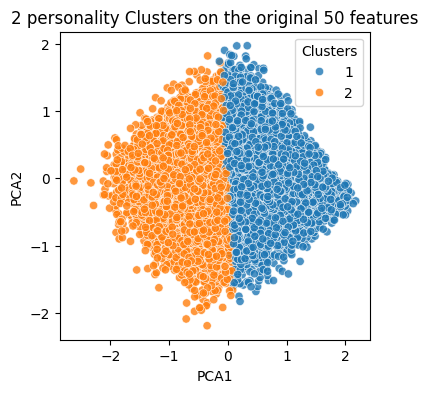

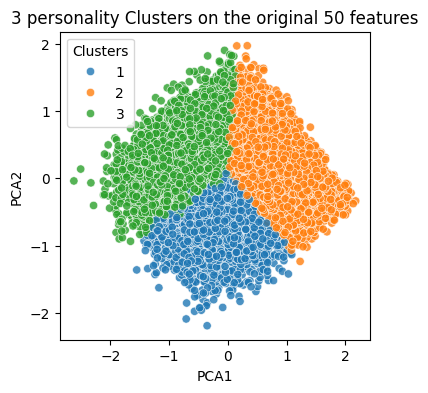

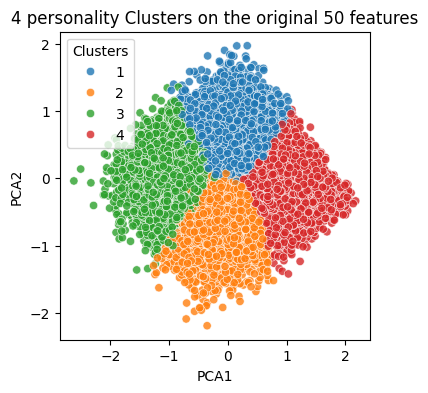

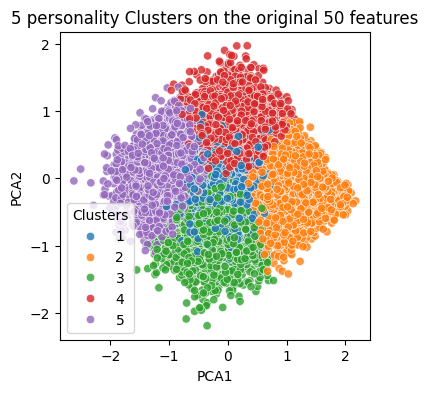

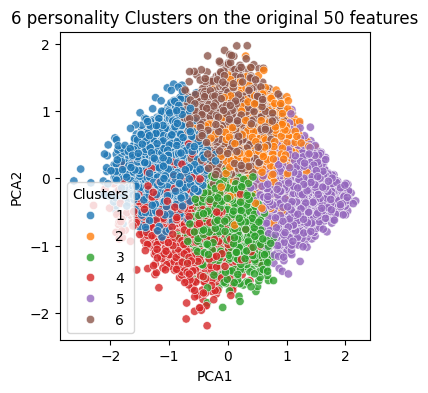

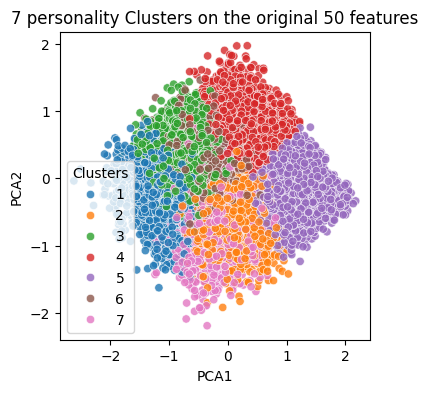

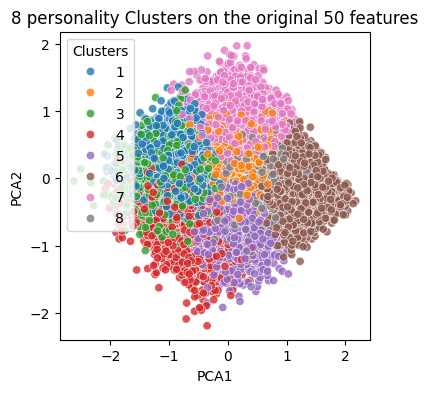

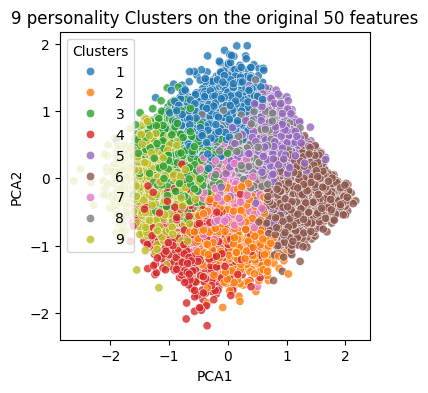

In [23]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# We need to convert numpy array to pandas data frame as needed by the given example code
# El ejemplo requiere que conviertamos un 'numpy array' a un 'data frame' de pandas
df_model = pd.DataFrame(data = data[:, 5:], columns = datacolumns[5:])

for k in range(2,10):
  # PCA
  pca = PCA(n_components=2)
  pca_fit = pca.fit_transform(df_model)
  df_pca = pd.DataFrame(data=pca_fit, columns=['PCA1', 'PCA2'])

  # kmeans
  kmeans = KMeans(n_clusters=k, n_init="auto")
  k_fit = kmeans.fit(df_model)

  # obteniendo los Clusters
  predictions = k_fit.labels_

  # agregando etiquetas de clúster
  df_pca['Clusters'] = predictions+1

  # Visualizando los clusters
  plt.figure(figsize=(4,4))
  sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Clusters', palette='tab10', alpha=0.8)
  plt.title(str(k) + ' personality Clusters on the original 50 features');
  plt.show()

## T4.A
- **Copia el código anterior en la siguiente celda y, en lugar de aplicar *k-means* a los datos originales, aplícalo a las características extraídas mediante PCA en 2D.** <font color='blue'>(0.5 puntos)</font>

<font color='red'>Proporcione la solución (código) en la siguiente celda.</font>

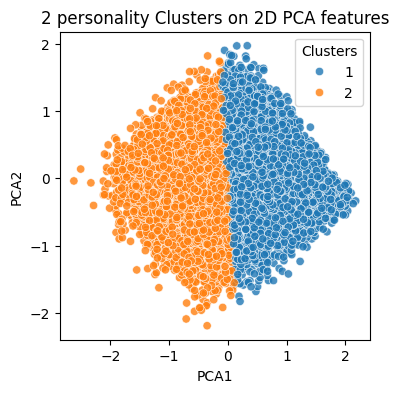

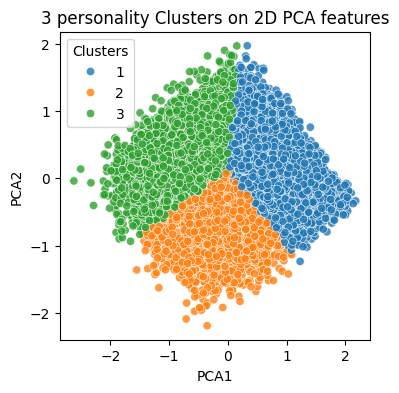

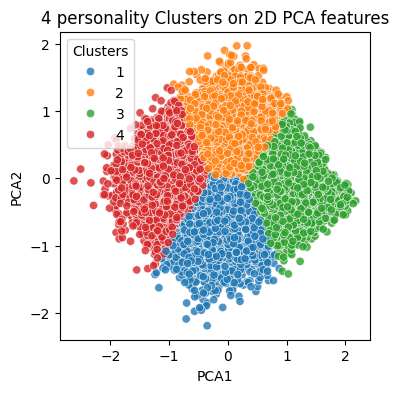

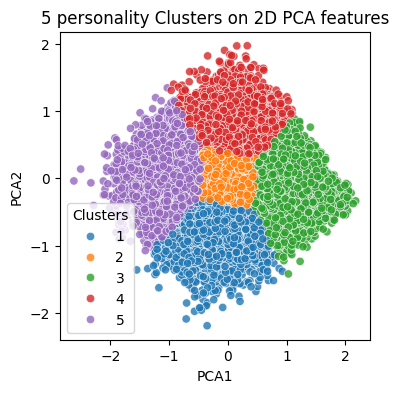

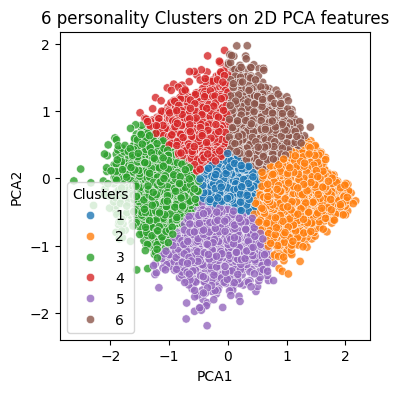

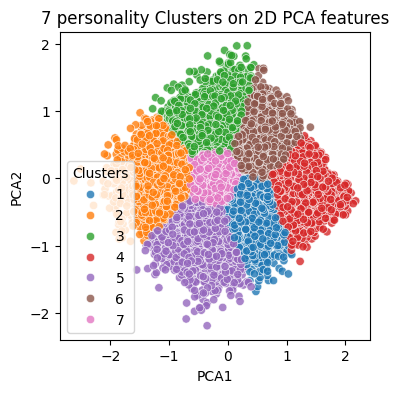

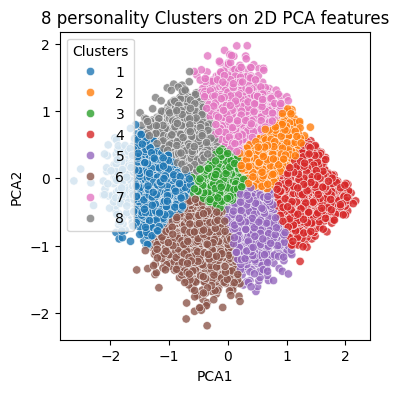

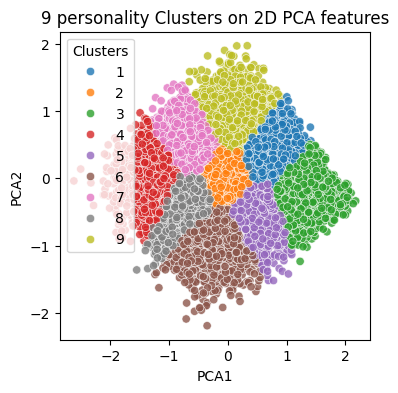

In [24]:
#------------------------------------
# Escribe tu código en este bloque
#------------------------------------
# kmeans con características PCA 2D, usando k=2 a 9
for k in range(2, 10):
    # PCA
    pca = PCA(n_components=2)
    pca_fit = pca.fit_transform(df_model)
    df_pca = pd.DataFrame(data=pca_fit, columns=['PCA1', 'PCA2'])

    # kmeans aplicado a las 2 características PCA (no a los 50 features originales)
    kmeans = KMeans(n_clusters=k, n_init="auto")
    k_fit = kmeans.fit(df_pca)  # ← única diferencia respecto al código original

    # obteniendo los Clusters
    predictions = k_fit.labels_

    # agregando etiquetas de clúster
    df_pca['Clusters'] = predictions + 1

    # Visualizando los clusters
    plt.figure(figsize=(4, 4))
    sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Clusters', palette='tab10', alpha=0.8)
    plt.title(str(k) + ' personality Clusters on 2D PCA features')
    plt.show()

# Introducción a las Tareas 4.B a 4.D
- *K-means* es un algoritmo que agrupa datos según su proximidad en un espacio de N dimensiones. Sin embargo, la visualización de datos con N > 3 dimensiones no es posible. Por eso proyectamos los datos a dimensiones más bajas utilizando PCA. Aunque en los datos originales no hay superposición entre los grupos, estos pueden parecer superpuestos al proyectarse en dimensiones más bajas.

- **Compara los nuevos gráficos que has generado (agrupamiento con características 2D obtenidas mediante PCA) con los gráficos anteriores (agrupamiento con datos en alta dimensión) y responde las siguientes preguntas.**



## T4.B

- ¿En qué se diferencian? (0.5 puntos)
<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font>
Al aplicar k-means sobre las 2 características PCA, los clusters aparecen claramente delimitados en la visualización, ya que el algoritmo optimiza el agrupamiento directamente en ese espacio 2D. En cambio, al aplicar k-means sobre los 50 features originales, los clusters pueden solaparse visualmente en la proyección 2D, aunque estén bien diferenciados en el espacio de alta dimensión original.

# T4.C
- **¿Qué tipo de características son más adecuadas para el clustering: las proyectadas en 2D mediante PCA o las de alta dimensión originales?** <font color='blue'>(0.5 puntos)</font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font> Las características de alta dimensión (50 features originales) son más adecuadas para el clustering, ya que contienen más información sobre los datos. La reducción a 2D mediante PCA retiene solo una parte de la varianza original (aproximadamente el 27%, descartando cerca del 73%), por lo que el agrupamiento puede perder calidad al realizarse en ese espacio reducido. Cabe tener en cuenta que PCA es principalmente una técnica orientada a la reducción de dimensionalidad y la visualización, por lo que utilizarla como espacio de agrupamiento puede no ser siempre la opción más óptima, aunque no invalida los resultados obtenidos.

# T4.D
- **¿Puede considerarse la visualización en 2D una herramienta confiable para determinar la calidad del agrupamiento?** <font color='blue'>(0.5 puntos)</font>

<font color='red'> Conteste aquí (haz doble clic en la celda para activar el editor): </font> No completamente. La visualización 2D mediante PCA es útil para obtener una impresión general de la separación entre grupos, pero no es una herramienta confiable para evaluar la calidad del clustering, ya que la proyección a 2 dimensiones puede distorsionar las distancias reales entre muestras en el espacio de alta dimensión. Clusters que parecen solaparse en 2D pueden estar perfectamente separados en el espacio original.